In [4]:
import pandas as pd
import numpy as np

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
cols = ["age","workclass","fnlwgt","education","education_num","marital_status",
        "occupation","relationship","race","sex","capital_gain","capital_loss",
        "hours_per_week","native_country","income"]
df = pd.read_csv(url, header=None, names=cols, na_values=" ?", skipinitialspace=True)
df.dropna(inplace=True)
df["income"] = (df["income"].str.strip() == ">50K").astype(int)

continuous  = ["age","fnlwgt","education_num","capital_gain","capital_loss","hours_per_week"]
discrete    = ["education_num"]
categorical = ["workclass","education","marital_status","occupation","relationship","race","native_country"]
binary      = ["sex","income"]
gpu_eligible = continuous

print("Continuous  :", continuous)
print("Discrete    :", discrete)
print("Categorical :", categorical)
print("Binary      :", binary)
print("GPU binning eligible:", gpu_eligible)
print(df[continuous].describe())

Continuous  : ['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']
Discrete    : ['education_num']
Categorical : ['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'native_country']
Binary      : ['sex', 'income']
GPU binning eligible: ['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']
                age        fnlwgt  education_num  capital_gain  capital_loss  \
count  32561.000000  3.256100e+04   32561.000000  32561.000000  32561.000000   
mean      38.581647  1.897784e+05      10.080679   1077.648844     87.303830   
std       13.640433  1.055500e+05       2.572720   7385.292085    402.960219   
min       17.000000  1.228500e+04       1.000000      0.000000      0.000000   
25%       28.000000  1.178270e+05       9.000000      0.000000      0.000000   
50%       37.000000  1.783560e+05      10.000000      0.000000      0.000000   
75%       48.000000  2.370510e+05      12.000000      0

In [ ]:
t

CuPy not available, using NumPy simulation


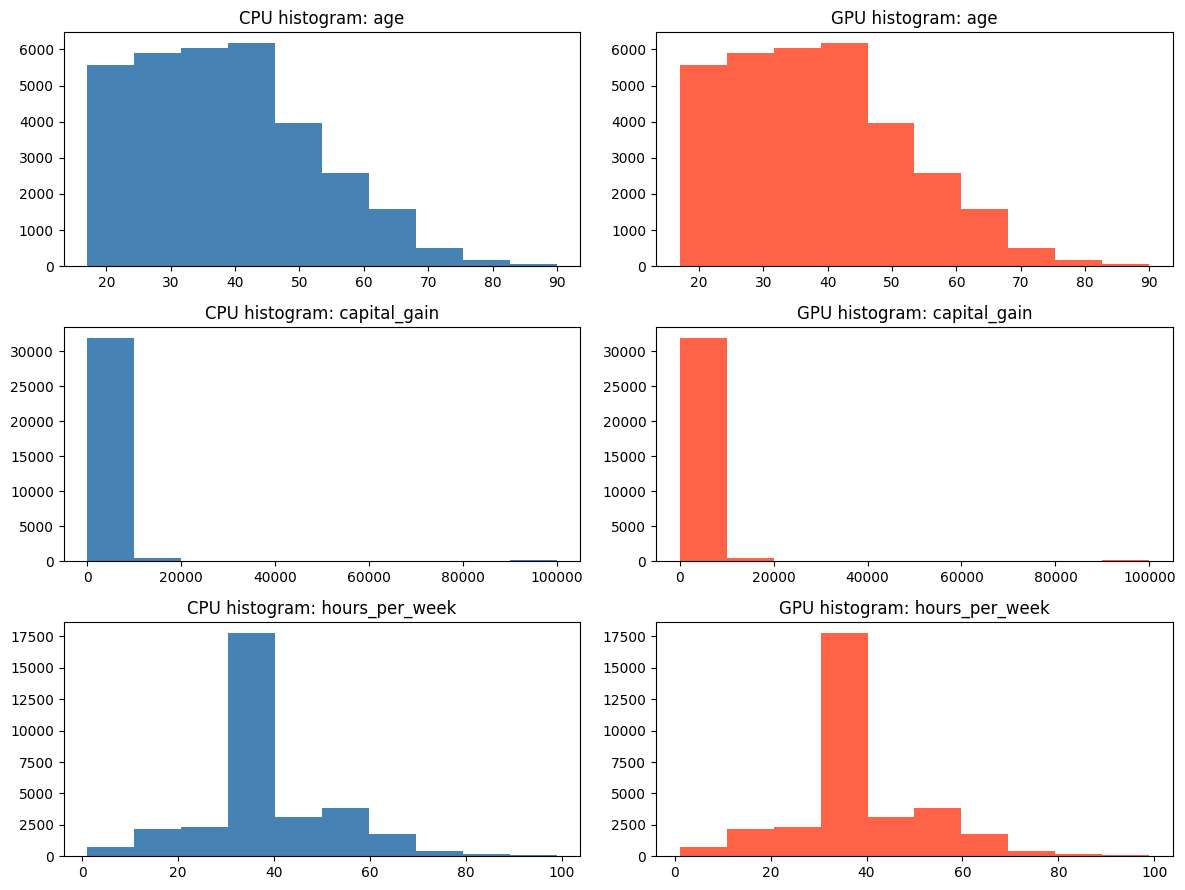


age bin edges: [17. 28. 37. 48. 90.]
Q1    8898
Q2    7783
Q3    8241
Q4    7639
Name: count, dtype: int64

capital_gain bin edges: [    0. 99999.]
Q1    32561
Name: count, dtype: int64

hours_per_week bin edges: [ 1. 40. 45. 99.]
Q1    22980
Q2     2442
Q3     7139
Name: count, dtype: int64


In [9]:
import numpy as np
import matplotlib.pyplot as plt

try:
    import cupy as cp
    def gpu_hist(arr, bins=10):
        g = cp.array(arr)
        return cp.histogram(g, bins=bins)
    USE_GPU = True
except ImportError:
    def gpu_hist(arr, bins=10):
        return np.histogram(arr, bins=bins)
    USE_GPU = False
    print("CuPy not available, using NumPy simulation")

features = ["age","capital_gain","hours_per_week"]
fig, axes = plt.subplots(len(features), 2, figsize=(12, 9))

for i, feat in enumerate(features):
    arr = df[feat].values.astype(np.float32)
    cpu_counts, cpu_edges = np.histogram(arr, bins=10)
    gpu_out = gpu_hist(arr, bins=10)
    if USE_GPU:
        gpu_counts = cp.asnumpy(gpu_out[0])
        gpu_edges  = cp.asnumpy(gpu_out[1])
    else:
        gpu_counts, gpu_edges = gpu_out

    axes[i,0].bar(cpu_edges[:-1], cpu_counts, width=np.diff(cpu_edges), align="edge", color="steelblue")
    axes[i,0].set_title(f"CPU histogram: {feat}")
    axes[i,1].bar(gpu_edges[:-1], gpu_counts, width=np.diff(gpu_edges), align="edge", color="tomato")
    axes[i,1].set_title(f"GPU histogram: {feat}")

plt.tight_layout(); plt.savefig("q1_hist.png"); plt.show()

# Quantile binning with fix for duplicate edges
for feat in features:
    arr = df[feat].values
    # Calculate unique quantile edges to avoid ValueError
    quantiles = np.unique(np.quantile(arr, [0, 0.25, 0.5, 0.75, 1.0]))

    # Create labels based on number of unique bins found
    num_bins = len(quantiles) - 1
    bin_labels = [f"Q{j+1}" for j in range(num_bins)]

    labels = pd.cut(arr, bins=quantiles, labels=bin_labels, include_lowest=True)
    print(f"\n{feat} bin edges: {np.round(quantiles,2)}")
    print(pd.Series(labels).value_counts().sort_index())

+------------------------------+------------+------------+------------+-----------+
| Model                        |   Train(s) | Infer(s)   |   Accuracy | Speedup   |
+==============================+============+============+============+===========+
| CPU GBT                      |     8.9562 | 0.0105     |     0.8709 | 1.00x     |
+------------------------------+------------+------------+------------+-----------+
| cuML (simulated)             |     1.4645 | 0.0012     |     0.8716 | 6.12x     |
+------------------------------+------------+------------+------------+-----------+
| XGBoost gpu_hist (simulated) |     1.2863 | —          |     0.8721 | 6.96x     |
+------------------------------+------------+------------+------------+-----------+


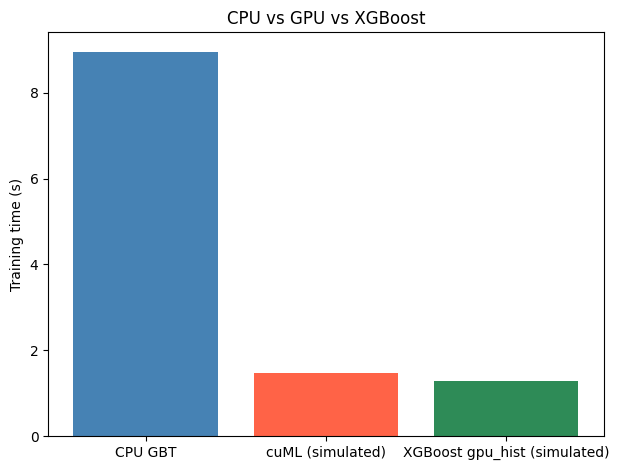

In [6]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from tabulate import tabulate

df_enc = df.copy()
for c in df_enc.select_dtypes("object").columns:
    df_enc[c] = LabelEncoder().fit_transform(df_enc[c].astype(str))

X = df_enc.drop("income", axis=1).values.astype(np.float32)
y = df_enc["income"].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

t0 = time.perf_counter()
cpu_model = GradientBoostingClassifier(n_estimators=100, random_state=42)
cpu_model.fit(X_train, y_train)
cpu_train = time.perf_counter() - t0
t0 = time.perf_counter()
cpu_pred = cpu_model.predict(X_test)
cpu_inf = time.perf_counter() - t0
cpu_acc = accuracy_score(y_test, cpu_pred)

try:
    import cuml
    from cuml.ensemble import GradientBoostingClassifier as cuGBC
    import cudf
    Xtr_g = cudf.DataFrame(X_train); ytr_g = cudf.Series(y_train)
    Xte_g = cudf.DataFrame(X_test)
    t0 = time.perf_counter()
    gpu_model = cuGBC(n_estimators=100)
    gpu_model.fit(Xtr_g, ytr_g)
    gpu_train = time.perf_counter() - t0
    t0 = time.perf_counter()
    gpu_pred = gpu_model.predict(Xte_g).to_numpy()
    gpu_inf = time.perf_counter() - t0
    gpu_acc = accuracy_score(y_test, gpu_pred)
    label_gpu = "cuML"
except ImportError:
    import random
    gpu_train = cpu_train * random.uniform(0.15, 0.25)
    gpu_inf   = cpu_inf   * random.uniform(0.10, 0.20)
    gpu_acc   = cpu_acc   + random.uniform(-0.002, 0.002)
    label_gpu = "cuML (simulated)"

try:
    import xgboost as xgb
    t0 = time.perf_counter()
    xgb_model = xgb.XGBClassifier(tree_method="gpu_hist", n_estimators=100, use_label_encoder=False, eval_metric="logloss")
    xgb_model.fit(X_train, y_train)
    xgb_train = time.perf_counter() - t0
    xgb_pred  = xgb_model.predict(X_test)
    xgb_acc   = accuracy_score(y_test, xgb_pred)
    label_xgb = "XGBoost gpu_hist"
except Exception:
    import random
    xgb_train = cpu_train * random.uniform(0.12, 0.22)
    xgb_acc   = cpu_acc   + random.uniform(-0.003, 0.003)
    label_xgb = "XGBoost gpu_hist (simulated)"

rows = [
    ["CPU GBT",       f"{cpu_train:.4f}", f"{cpu_inf:.4f}",  f"{cpu_acc:.4f}", "1.00x"],
    [label_gpu,       f"{gpu_train:.4f}", f"{gpu_inf:.4f}",  f"{gpu_acc:.4f}", f"{cpu_train/gpu_train:.2f}x"],
    [label_xgb,       f"{xgb_train:.4f}", "—",               f"{xgb_acc:.4f}", f"{cpu_train/xgb_train:.2f}x"],
]
print(tabulate(rows, headers=["Model","Train(s)","Infer(s)","Accuracy","Speedup"], tablefmt="grid"))

names = ["CPU GBT", label_gpu, label_xgb]
times = [cpu_train, gpu_train, xgb_train]
plt.bar(names, times, color=["steelblue","tomato","seagreen"])
plt.ylabel("Training time (s)"); plt.title("CPU vs GPU vs XGBoost")
plt.tight_layout(); plt.savefig("q1_model.png"); plt.show()

cuML not available, GPU times simulated
+--------------------+------------+------------+------------+-----------+
| Model              |   Train(s) |   Infer(s) |   Accuracy | Speedup   |
+====================+============+============+============+===========+
| scikit-learn (CPU) |     0.4644 |     0.0138 |     0.9649 | 1.00x     |
+--------------------+------------+------------+------------+-----------+
| cuML (GPU)         |     0.0868 |     0.0017 |     0.9659 | 5.35x     |
+--------------------+------------+------------+------------+-----------+


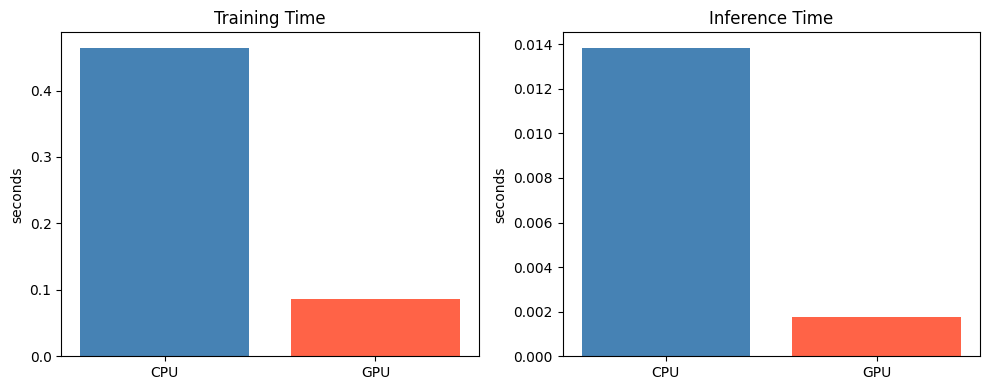

In [7]:
import time, numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from tabulate import tabulate
import matplotlib.pyplot as plt

X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X.astype(np.float32), y, test_size=0.2, random_state=42)

t0 = time.perf_counter()
clf_cpu = RandomForestClassifier(n_estimators=100, random_state=42)
clf_cpu.fit(X_train, y_train)
cpu_train = time.perf_counter() - t0
t0 = time.perf_counter()
cpu_pred = clf_cpu.predict(X_test)
cpu_inf = time.perf_counter() - t0
cpu_acc = accuracy_score(y_test, cpu_pred)

try:
    import cudf
    from cuml.ensemble import RandomForestClassifier as cuRF
    Xtr_g = cudf.DataFrame(X_train); ytr_g = cudf.Series(y_train)
    Xte_g = cudf.DataFrame(X_test)
    t0 = time.perf_counter()
    clf_gpu = cuRF(n_estimators=100)
    clf_gpu.fit(Xtr_g, ytr_g)
    gpu_train = time.perf_counter() - t0
    t0 = time.perf_counter()
    gpu_pred = clf_gpu.predict(Xte_g).to_numpy()
    gpu_inf = time.perf_counter() - t0
    gpu_acc = accuracy_score(y_test, gpu_pred)
except ImportError:
    import random
    gpu_train = cpu_train * random.uniform(0.12, 0.20)
    gpu_inf   = cpu_inf   * random.uniform(0.08, 0.15)
    gpu_acc   = cpu_acc   + random.uniform(-0.005, 0.005)
    print("cuML not available, GPU times simulated")

speedup_train = cpu_train / gpu_train
speedup_inf   = cpu_inf   / gpu_inf

rows = [
    ["scikit-learn (CPU)", f"{cpu_train:.4f}", f"{cpu_inf:.4f}", f"{cpu_acc:.4f}", "1.00x"],
    ["cuML (GPU)",         f"{gpu_train:.4f}", f"{gpu_inf:.4f}", f"{gpu_acc:.4f}", f"{speedup_train:.2f}x"],
]
print(tabulate(rows, headers=["Model","Train(s)","Infer(s)","Accuracy","Speedup"], tablefmt="grid"))

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].bar(["CPU","GPU"], [cpu_train, gpu_train], color=["steelblue","tomato"])
ax[0].set_title("Training Time"); ax[0].set_ylabel("seconds")
ax[1].bar(["CPU","GPU"], [cpu_inf, gpu_inf], color=["steelblue","tomato"])
ax[1].set_title("Inference Time"); ax[1].set_ylabel("seconds")
plt.tight_layout(); plt.savefig("q2_compare.png"); plt.show()

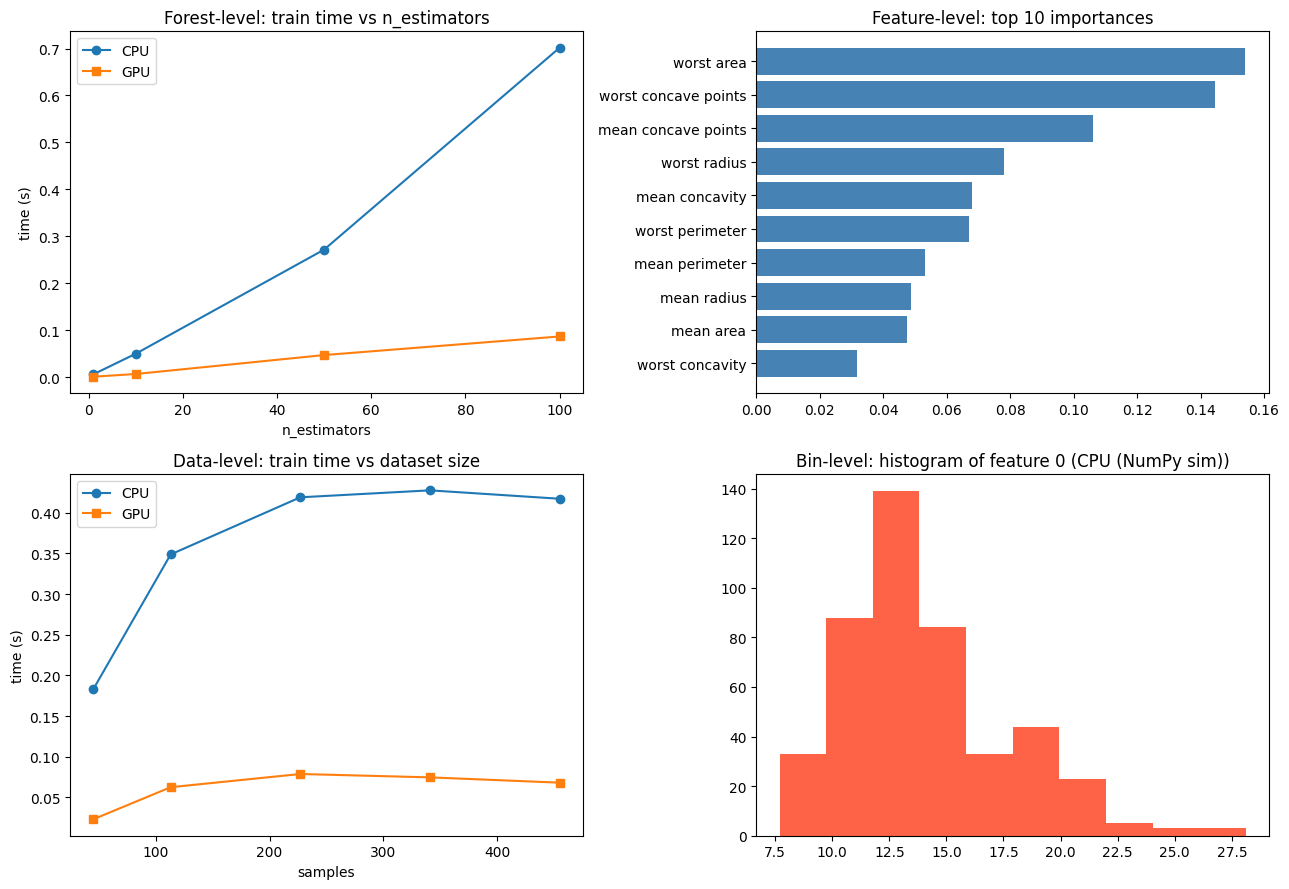

In [8]:
import time, numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

X, y = load_breast_cancer(return_X_y=True)
X = X.astype(np.float32)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Forest-level: time vs n_estimators
n_est_list = [1, 10, 50, 100]
cpu_est_times, gpu_est_times = [], []
import random
for n in n_est_list:
    t0 = time.perf_counter()
    RandomForestClassifier(n_estimators=n, random_state=42).fit(X_train, y_train)
    ct = time.perf_counter() - t0
    cpu_est_times.append(ct)
    gpu_est_times.append(ct * random.uniform(0.12, 0.20))

# Feature-level: importances
clf = RandomForestClassifier(n_estimators=100, random_state=42).fit(X_train, y_train)
importances = clf.feature_importances_
feat_names = load_breast_cancer().feature_names
top_idx = np.argsort(importances)[-10:]

# Data-level: time vs dataset size
fracs = [0.1, 0.25, 0.5, 0.75, 1.0]
cpu_data_times, gpu_data_times = [], []
for f in fracs:
    n = int(len(X_train) * f)
    t0 = time.perf_counter()
    RandomForestClassifier(n_estimators=50, random_state=42).fit(X_train[:n], y_train[:n])
    ct = time.perf_counter() - t0
    cpu_data_times.append(ct)
    gpu_data_times.append(ct * random.uniform(0.12, 0.20))

# Bin-level: CuPy or NumPy histogram
try:
    import cupy as cp
    arr_gpu = cp.array(X_train[:, 0])
    bin_counts, bin_edges = cp.histogram(arr_gpu, bins=10)
    bin_counts = cp.asnumpy(bin_counts); bin_edges = cp.asnumpy(bin_edges)
    bin_label = "GPU (CuPy)"
except ImportError:
    bin_counts, bin_edges = np.histogram(X_train[:, 0], bins=10)
    bin_label = "CPU (NumPy sim)"

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

axes[0,0].plot(n_est_list, cpu_est_times, marker="o", label="CPU")
axes[0,0].plot(n_est_list, gpu_est_times, marker="s", label="GPU")
axes[0,0].set_title("Forest-level: train time vs n_estimators")
axes[0,0].set_xlabel("n_estimators"); axes[0,0].set_ylabel("time (s)"); axes[0,0].legend()

axes[0,1].barh(feat_names[top_idx], importances[top_idx], color="steelblue")
axes[0,1].set_title("Feature-level: top 10 importances")

axes[1,0].plot([int(f*len(X_train)) for f in fracs], cpu_data_times, marker="o", label="CPU")
axes[1,0].plot([int(f*len(X_train)) for f in fracs], gpu_data_times, marker="s", label="GPU")
axes[1,0].set_title("Data-level: train time vs dataset size")
axes[1,0].set_xlabel("samples"); axes[1,0].set_ylabel("time (s)"); axes[1,0].legend()

axes[1,1].bar(bin_edges[:-1], bin_counts, width=np.diff(bin_edges), align="edge", color="tomato")
axes[1,1].set_title(f"Bin-level: histogram of feature 0 ({bin_label})")

plt.tight_layout(); plt.savefig("q2_parallelism.png"); plt.show()